In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df= pd.read_csv("/content/heart_disease_data.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
## Check for missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
## check for duplicates
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [8]:
## Drop duplicates
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

0

In [11]:
## check for shape
df.shape

(302, 14)

In [12]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [13]:
## Split the dataset
X= df.iloc[:,:-1]
y=df.iloc[:,-1]

In [14]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [15]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


<Axes: >

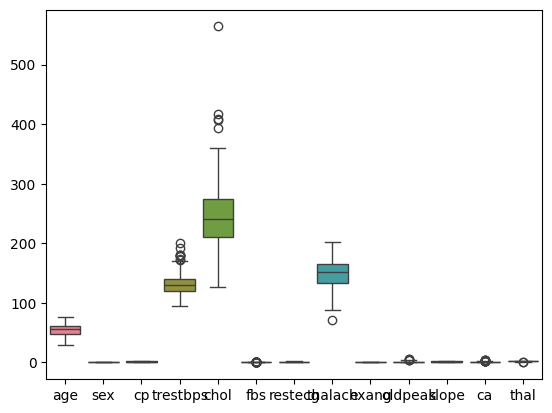

In [16]:
## check for outliers
sns.boxplot(X)

In [19]:
## use train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=7)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(226, 13) (226,)
(76, 13) (76,)


In [20]:
## Use Logistic regression

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

y_pred= model.predict(X_test)

## Metrics
from sklearn.metrics import accuracy_score, classification_report
acc_score= accuracy_score(y_test,y_pred)
report= classification_report(y_test,y_pred)

print(f"Accuarcy Score: {acc_score}")
print(f"Classification report : {report}")

Accuarcy Score: 0.881578947368421
Classification report :               precision    recall  f1-score   support

           0       0.94      0.82      0.88        39
           1       0.83      0.95      0.89        37

    accuracy                           0.88        76
   macro avg       0.89      0.88      0.88        76
weighted avg       0.89      0.88      0.88        76



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
input_data= [64,1,3,110,211,0,0,144,1,1.8,1,0,2]
input_arr= np.asarray(input_data)

prediction = model.predict(input_arr.reshape(1,-1))
if prediction == 0:
  print("Negative report on Heart disease")
else:
  print("You are tested positive for Heart Disease")

You are tested positive for Heart Disease


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [26]:


input_data= [60,1,0,117,230,1,1,160,1,1.4,2,2,3]
input_arr= np.asarray(input_data)

prediction = model.predict(input_arr.reshape(1,-1))
if prediction == 0:
  print("Negative report, You dont have a Heart disease")
else:
  print("You are tested positive for Heart Disease")

Negative report, You dont have a Heart disease


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
